In [9]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt
import numpy as np

# 数据
X = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0]])
y = torch.tensor([[3.0], [5.0], [7.0], [9.0], [11.0]])


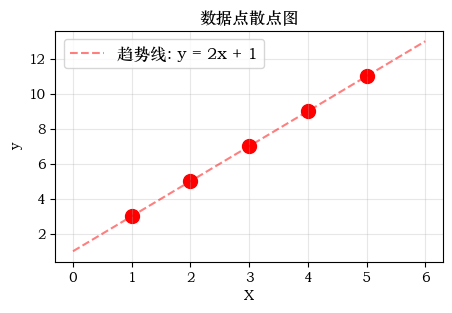

In [15]:
plt.figure(figsize=(5, 3))
plt.scatter(X.numpy(), y.numpy(), color='red', s=100)
# 添加趋势线（因为这是完美的线性关系）
x_line = np.linspace(0, 6, 100)
y_line = 2*x_line + 1  # 根据数据点推断的直线 y = 2x + 1
plt.plot(x_line, y_line, 'r--', alpha=0.5, label='趋势线: y = 2x + 1')
plt.xlabel('X')
plt.ylabel('y')
plt.title('数据点散点图')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
import torch.nn as nn
import torch.optim as optim

model = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

loss_history = []

for epoch in range(200):
    # 1. 前向传播
    y_pred = model(X)
    loss = criterion(y_pred, y)

    # 2. 梯度清零
    optimizer.zero_grad()

    # 3. 反向传播
    loss.backward()

    # 4. 更新参数
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 20 == 0:
        print(f"epoch {epoch:3d}, loss = {loss.item():.6f}")

epoch   0, loss = 47.251381
epoch  20, loss = 0.001164
epoch  40, loss = 0.000174
epoch  60, loss = 0.000152
epoch  80, loss = 0.000133
epoch 100, loss = 0.000116
epoch 120, loss = 0.000101
epoch 140, loss = 0.000089
epoch 160, loss = 0.000077
epoch 180, loss = 0.000068


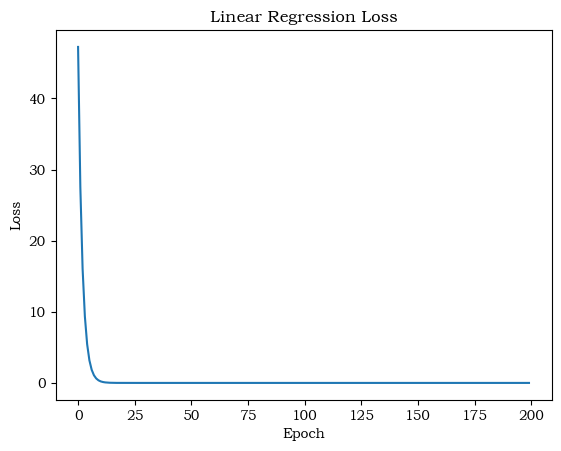

In [19]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Linear Regression Loss")
plt.show()

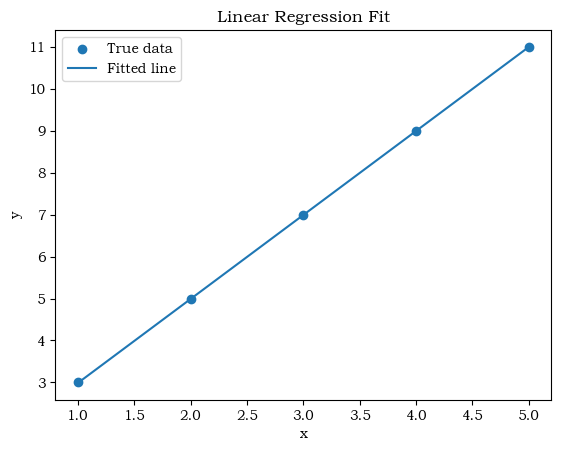

In [20]:
with torch.no_grad():
    y_fit = model(X)

plt.scatter(X.numpy(), y.numpy(), label="True data")
plt.plot(X.numpy(), y_fit.numpy(), label="Fitted line")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.show()